# Pseudo Probability Functions

## Imports

In [49]:
import matplotlib.pylab as plt
import numpy as np
import matplotlib as mpl
from matplotlib import cm
from qutip import *

%matplotlib inline

## Wigner function for superposition of fock states

The **Wigner function** (or Wigner quasiprobability distribution) is a mathematical tool that represents quantum states in phase space — the same space used in classical mechanics where a particle has both a position x  and momentum p .

Provides a bridge between quantum and classical mechanics

$W(x,p)$ is the closest quantum analog to a classical phase-space distribution, with negativity as the hallmark of quantum coherence

In [50]:
x = 1.0 / np.sqrt(2) * (basis(10, 4) + basis(10, 2))    # Creating the Quantum State
xvec = np.arange(-5, 5, 10.0 / 100)                     # Position Grid
yvec = xvec                                             # Momentum Grid
W = wigner(x, xvec, yvec)                               # Computing the Wigner Function => Returns a 100 x 100 matrix
cmap = wigner_cmap(W)                                   # Custom ColorMap
X, Y = np.meshgrid(xvec, yvec)                          # Creating The Meshgrid => 2D mesh grids for plotting

`Line 1`: 
```python
x = 1.0 / np.sqrt(2) * (basis(10, 4) + basis(10, 2))    # Creating the Quantum State
```

Component by Component:
| Code               | Meaning                                                   |
| ------------------ | --------------------------------------------------------- |
| `basis(10, 4)`     | Fock state $\|4\rangle$ in a 10-dimensional Hilbert space |
| `basis(10, 2)`     | Fock state $\|2\rangle$ in a 10-dimensional Hilbert space |
| `+`                | Superposition (quantum addition)                          |
| `1.0 / np.sqrt(2)` | Normalization factor $1/\sqrt{2} \approx 0.707$           |

The Resulting state:
$$ |x\rangle = \frac{1}{\sqrt 2} |4\rangle + \frac{1}{\sqrt 2} |2\rangle  = \frac{|4\rangle + |2\rangle}{\sqrt 2} $$
This is an equal superposition of two number states (Fock states).

---

`Line 2`:
```python
xvec = np.arange(-5, 5, 10.0 / 100)                     # Position Grid
```

| Component          | Value            | Meaning                          |
| ------------------ | ---------------- | -------------------------------- |
| `-5`               | Start            | Minimum position $x_{\min} = -5$ |
| `5`                | Stop (exclusive) | Maximum position $x_{\max} = 5$  |
| `10.0 / 100 = 0.1` | Step size        | $\Delta x = 0.1$                 |


---

`Line 5`: 

A specialized colormap designed specifically for Wigner functions
| Feature                   | Purpose                                       |
| ------------------------- | --------------------------------------------- |
| **Diverging colors**      | Distinguishes positive vs negative values     |
| **Zero-centered**         | White at $W = 0$                              |
| **Blue for positive**     | Classical-like regions                        |
| **Red/Pink for negative** | Quantum regions (the "quantumness indicator") |


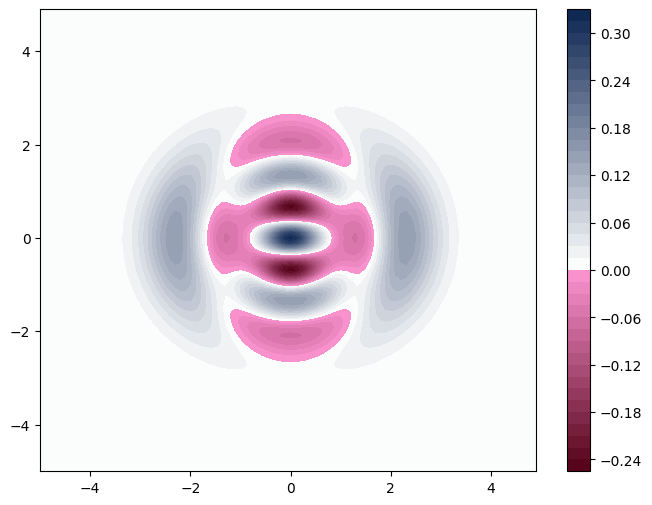

In [51]:
fig = plt.figure(figsize=(8, 6))
plt.contourf(X, Y, W, 50, cmap=cmap)
plt.colorbar();     # Adding the Colorbar(Creates a vertical scale on the side showing the mapping)

`Line 2`: **The Core Visualization**
```python
plt.contourf(X, Y, W, 50, cmap=cmap)
```
**Function**: `contourf` = Contour Fill
| Argument | Role                     | In This Code                    |
| -------- | ------------------------ | ------------------------------- |
| `X`      | Horizontal coordinates   | Position $x$ (meshgrid)         |
| `Y`      | Vertical coordinates     | Momentum $p$ (meshgrid)         |
| `W`      | Height values            | Wigner function values $W(x,p)$ |
| `50`     | Number of contour levels | 50 distinct color bands         |
| `cmap`   | Color mapping            | Custom Wigner colormap          |

What `contourf` Does:
- Finds the range of `W` values: $[W_{min},W_{max}]$ 
- Divides this range into 50 equal intervals (levels)
- Assigns colors from `cmap` to each interval
- Fills regions between contour lines with solid color

Visual Results:
| Region           | Location                         | Color                | W Value        | Physical Meaning                 |
| ---------------- | -------------------------------- | -------------------- | -------------- | -------------------------------- |
| **Central peak** | $(x \approx 0, p \approx 0)$     | **Dark blue**        | **~0.30**      | Maximum probability density      |
| **Upper lobe**   | $(x \approx 0, p \approx +2.5)$  | **Pink**             | **~-0.06**     | Quantum interference (negative!) |
| **Lower lobe**   | $(x \approx 0, p \approx -2.5)$  | **Pink**             | **~-0.06**     | Quantum interference (negative!) |
| **Side wings**   | $(x \approx \pm 2, p \approx 0)$ | **Light blue/white** | **~0.06-0.12** | Positive but smaller             |
| **Outer rings**  | $(x^2 + p^2 \approx 16)$         | **Fading white**     | **→ 0**        | Exponential tail of Fock states  |


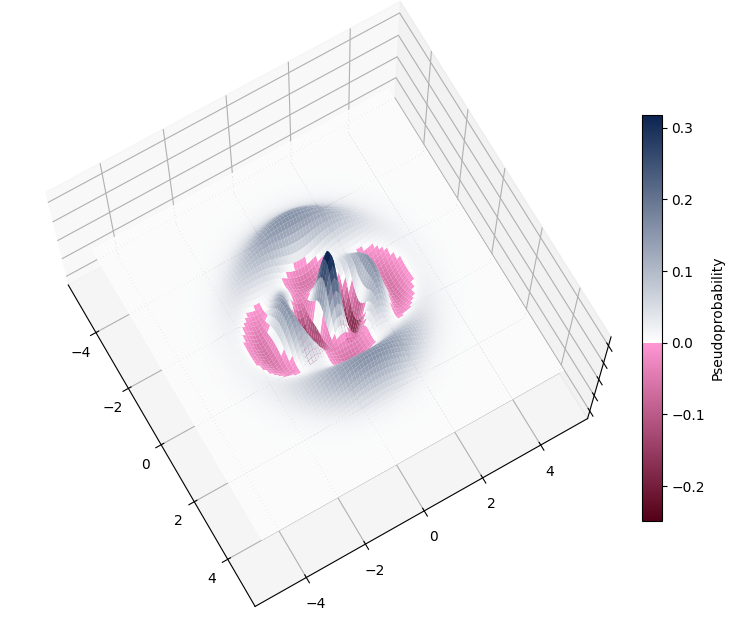

In [52]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d', azim=-30, elev=73)   # Creating 3D Axes
ax.plot_surface(X, Y, W, cmap=cmap, rstride=1, cstride=1, alpha=1, linewidth=0)     # The 3D Surface
ax.set_zlim3d(-0.25, 0.25)      # Fixing Z-Axis Limits

# Hiding Z-Axis Ticks
for a in ax.zaxis.get_ticklines() + ax.zaxis.get_ticklabels():
    a.set_visible(False)

# Custom Colorbar
nrm = mpl.colors.Normalize(W.min(), W.max())
cax, kw = mpl.colorbar.make_axes(ax, shrink=0.66, pad=0.02)
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=nrm)
cb1.set_label("Pseudoprobability")

`Line 2`: **Creating 3D Axes**

| Argument          | Value           | Meaning                                              |
| ----------------- | --------------- | ---------------------------------------------------- |
| `111`             | Grid position   | 1 row, 1 column, 1st subplot (single full figure)    |
| `projection='3d'` | 3D projection   | Activates 3D rendering engine (mplot3d)              |
| `azim=-30`        | Azimuth angle   | Rotate **-30° around z-axis** (view from left-front) |
| `elev=73`         | Elevation angle | Look from **73° above horizontal** (bird's eye view) |

Think: **"looking down into a crater from above and left"**

---

`Line 3`: **The 3D Surface**
```python
ax.plot_surface(X, Y, W, cmap=cmap, rstride=1, cstride=1, alpha=1, linewidth=0)
```
| Argument      | Value           | Function                                     |
| ------------- | --------------- | -------------------------------------------- |
| `X, Y`        | Meshgrids       | Horizontal coordinates (position & momentum) |
| `W`           | 2D array        | **Height** (z-axis) = Wigner function value  |
| `cmap=cmap`   | Custom colormap | Colors surface by W value (same as 2D)       |
| `rstride=1`   | Row stride=1    | Use **every** row of data (no skipping)      |
| `cstride=1`   | Column stride=1 | Use **every** column (maximum resolution)    |
| `alpha=1`     | Opacity=100%    | Fully opaque surface                         |
| `linewidth=0` | No edge lines   | Smooth surface without grid lines            |

---

| Aspect               | 2D `contourf`       | 3D `plot_surface`                      |
| -------------------- | ------------------- | -------------------------------------- |
| **Data encoding**    | Color only          | Height + Color                         |
| **Negative regions** | Pink areas          | **Actual valleys** you can "look into" |
| **Interference**     | Flat rings          | **Rippled terrain**                    |
| **Perception**       | Pattern recognition | **Depth/structure intuition**          |
| **Speed**            | Fast (0.1s)         | Slower (1.3s)                          |
| **Clarity**          | Precise values      | Dramatic visualization                 |


## Wigner and Q-function for Squeezed states

In [53]:
N = 20
alpha = -1.0  # Coherent amplitude of field
epsilon = 0.5j  # Squeezing parameter
a = destroy(N)

D = (alpha * a.dag() - np.conj(alpha) * a).expm()  # Displacement
S = (
    0.5 * np.conj(epsilon) * a * a - 0.5 * epsilon * a.dag() * a.dag()
).expm()  # Squeezing
psi = D * S * basis(N, 0)  # Apply to vacuum state
g=2

| Variable         | Value                   | Physical Meaning                                                                                                          |
| ---------------- | ----------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| `N = 20`         | Hilbert space dimension | Truncation at 20 photons (states \|0⟩ to \|19⟩)                                                                           |
| `alpha = -1.0`   | Complex number          | **Displacement amplitude** — shifts state in phase space by distance \|\|α\|\| = 1, direction = 180° (negative real axis) |
| `epsilon = 0.5j` | Pure imaginary          | **Squeezing parameter** — ζ = 0.5i (squeezing along specific quadrature)                                                  |
| `a = destroy(N)` | 20×20 matrix            | **Annihilation operator** $\hat{a}$: lowers photon number, $\hat{a}\|n\rangle = \sqrt{n}\|n-1\rangle$                     |

`Displacement Operator`:
```python
D = (alpha * a.dag() - np.conj(alpha) * a).expm()  # Displacement
```
**Mathematical Formula**: $$ \hat{D}(\alpha) = exp(\alpha \hat{a}\dagger - \alpha^*\hat{a}) $$

`What it does`:
- Shifts any state in phase space by vector α 
- Applied to vacuum: creates coherent state $∥α⟩= \hat D(α)∥0⟩$ 
- Here α=−1 : shift left by 1 unit on real axis

`Code Breakdown`:
| Component            | Meaning                               |
| -------------------- | ------------------------------------- |
| `a.dag()`            | Creation operator $\hat{a}^\dagger$   |
| `alpha * a.dag()`    | $\alpha \hat{a}^\dagger$              |
| `np.conj(alpha) * a` | $\alpha^* \hat{a}$                    |
| `.expm()`            | Matrix exponential (unitary operator) |


`Squeezing Operator`:
```python
S = (
    0.5 * np.conj(epsilon) * a * a 
    - 0.5 * epsilon * a.dag() * a.dag()
).expm()  # Squeezing
```

**What it does**:
- Squeezes uncertainty in one quadrature
- Stretches uncertainty in the conjugate quadrature
- Preserves minimum uncertainty product (saturates Heisenberg)

**Mathematical formula**:
$$ \hat S = exp(\frac{1}{2} \epsilon^* \hat a^2 - \frac{1}{2} \epsilon \hat a^{\dagger 2}) $$

**Parameter analysis**:
| Parameter              | Value                     | Effect                                               |
| ---------------------- | ------------------------- | ---------------------------------------------------- |
| $\zeta = re^{i\theta}$ | $r = 0.5$, $\theta = 90°$ | Squeezing angle = 45° (since $\theta/2$)             |
| $r = 0.5$              | Moderate squeezing        | ~4.8 dB squeezing (for small $r$: $\approx 8.7r$ dB) |



### Wigner Function

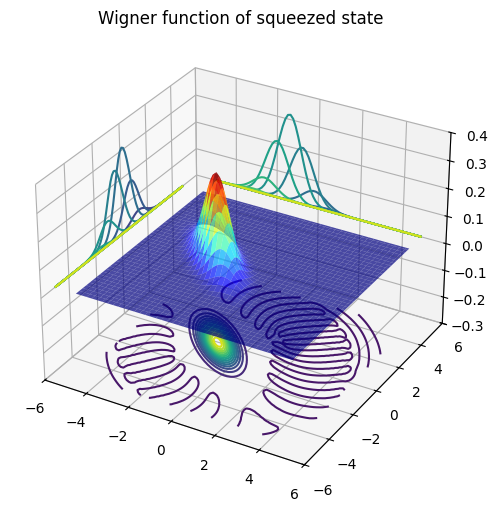

In [54]:
xvec = np.arange(-40.0, 40.0) * 5.0 / 40
X, Y = np.meshgrid(xvec, xvec)

W = wigner(psi, xvec, xvec)

fig1 = plt.figure(figsize=(8, 6))
ax = fig1.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, W, rstride=2, cstride=2, cmap=cm.jet, alpha=0.7)
ax.contour(X, Y, W, 15, zdir="x", offset=-6)
ax.contour(X, Y, W, 15, zdir="y", offset=6)
ax.contour(X, Y, W, 15, zdir="z", offset=-0.3)
ax.set_xlim3d(-6, 6)
ax.set_ylim3d(-6, 6)
ax.set_zlim3d(-0.3, 0.4)
plt.title("Wigner function of squeezed state");

### Q-Function

The Husimi Q-function (or Q-distribution) is a quasiprobability distribution used in quantum optics to map a density matrix onto phase space using coherent states

It represents the diagonal expansion of the density operator, acting as a smoothed, positive-valued version of the Wigner function that represents the probability of a system being in a particular coherent state

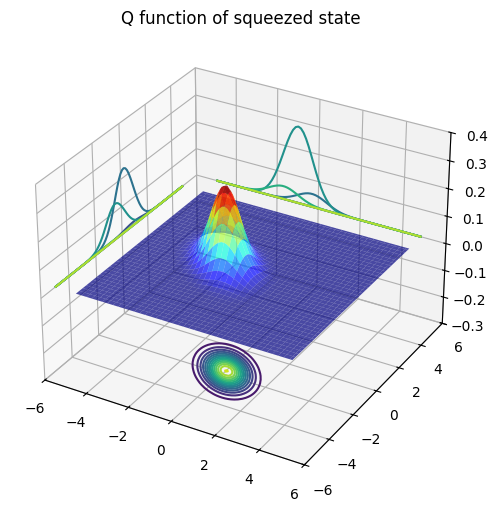

In [55]:
Q = qfunc(psi, xvec, xvec, g)

fig2 = plt.figure(figsize=(8, 6))
ax = fig2.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Q, rstride=2, cstride=2, cmap=cm.jet, alpha=0.7)
ax.contour(X, Y, Q, zdir="x", offset=-6)
ax.contour(X, Y, Q, zdir="y", offset=6)
ax.contour(X, Y, Q, 15, zdir="z", offset=-0.4)
ax.set_xlim3d(-6, 6)
ax.set_ylim3d(-6, 6)
ax.set_zlim3d(-0.3, 0.4)
plt.title("Q function of squeezed state");

`The Three Contour Projections`:
```python
ax.contour(X, Y, W, 15, zdir="x", offset=-6)
ax.contour(X, Y, W, 15, zdir="y", offset=6)
ax.contour(X, Y, W, 15, zdir="z", offset=-0.3)
```

This creates a **"box" of contours** — 2D slices projected onto the walls and floor!
| Line | Direction  | Offset | Location                | Purpose                      |
| ---- | ---------- | ------ | ----------------------- | ---------------------------- |
| 1st  | `zdir="x"` | -6     | **Left wall** (x = -6)  | Shows W vs (y,z) at x = -6   |
| 2nd  | `zdir="y"` | +6     | **Right wall** (y = +6) | Shows W vs (x,z) at y = +6   |
| 3rd  | `zdir="z"` | -0.3   | **Floor** (z = -0.3)    | Shows W vs (x,y) at W = -0.3 |


### Schrodinger cat state

In quantum mechanics, a Schrödinger cat state refers to a quantum system that exists in a superposition of two macroscopically distinct states. The term originated from Erwin Schrödinger’s 1935 thought experiment, where a hypothetical cat in a sealed box is simultaneously "alive" and "dead" until observed, intended as a critique to show the absurdity of applying quantum rules to everyday objects.

`Key Concepts`:
- **Superposition**: The principle that a physical system exists in all its possible theoretical states simultaneously until it is measured.
- **The Paradox**: In Schrödinger's setup, a cat's life is linked to a random subatomic event (radioactive decay). If the atom decays, poison is released. Because the atom is in a superposition of "decayed" and "not decayed," the cat must also be in a superposition of "dead" and "alive".
- **Measurement and Collapse**: According to the Copenhagen interpretation, the act of observing or measuring the system causes the "wavefunction" to collapse into one definite state.

In [66]:
N = 20
# Amplitude of coherent states
alpha1 = -2.0 - 2j
alpha2 = 2.0 + 2j

# Define Ladder operators
a = destroy(N) # Annihilation operator in 20 x 20 matrix

# Define Displacement operators
D1 = (alpha1 * a.dag() - np.conj(alpha1) * a).expm()
D2 = (alpha2 * a.dag() - np.conj(alpha2) * a).expm()

# Sum of coherent states
psi = np.sqrt(2) ** -1 * (D1 + D2) * basis(N, 0);

`Coherent State Amplitudes`:
```python 
alpha1 = -2.0 - 2j
alpha2 = 2.0 + 2j
```
| Parameter | Value     | Phase Space Location             |
| --------- | --------- | -------------------------------- |
| `alpha1`  | $-2 - 2i$ | Third quadrant: $x = -2, p = -2$ |
| `alpha2`  | $+2 + 2i$ | First quadrant: $x = +2, p = +2$ |

**Distance between states**: 

This is **macroscopically separated** — the "cat" is alive and dead in different corners of phase space!

`Sum of Coherent States`:

```text
|0⟩ ---> D1|0⟩ + D2|0⟩ ---> normalize
       = |α₁⟩ + |α₂⟩     = (|α₁⟩ + |α₂⟩)/√2
```

**Physical Meaning**:

This is a **quantum superposition** where the field is simultaneously:
- **Localized at** (-2, -2) in phase space
- **Localized at** (+2, +2) in phase space

Like a cat being **both alive and dead** — but for a quantum harmonic oscillator!